# Connect Jupyter to Mysql

In [41]:
from sqlalchemy import create_engine
import pandas as pd
import matplotlib.pyplot as plt
username = "root"
password = "Santhosh%40578"  
host = "localhost"
port = 3306
database = "ecommerce"
connection_url = f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
engine = create_engine(connection_url)
connection = engine.connect()
df = pd.read_sql("SHOW TABLES", con=connection)
print(df)

  Tables_in_ecommerce
0        dataanalysis
1  e-commerce dataset
2           ecommerce
3              orders
4               sales
5          sales_data


## Run queries

In [42]:
df=pd.read_sql('select * from sales_data',con=connection)
df

,id,name,buydate,productname,sales
0,120,santhosh,2023-01-10,Electronics,40000
1,121,vamsee,2023-01-12,clothing,90000
2,122,shanmukha,2023-01-14,books,50000
3,123,thiru,2023-01-15,sports,39000
4,124,shanmukha,2023-01-18,beauty products,60000
5,125,uday,2023-01-20,Electronics,30000
6,126,sai,2023-01-22,sports,52000
7,127,vignesh,2023-01-25,beauty products,82000
8,128,varun,2023-01-27,clothing,44000


In [72]:
df=pd.read_sql('select buydate,sales from sales_data',con=connection)
df

,buydate,sales
0,2023-01-10,40000
1,2023-01-12,90000
2,2023-01-14,50000
3,2023-01-15,39000
4,2023-01-18,60000
5,2023-01-20,30000
6,2023-01-22,52000
7,2023-01-25,82000
8,2023-01-27,44000


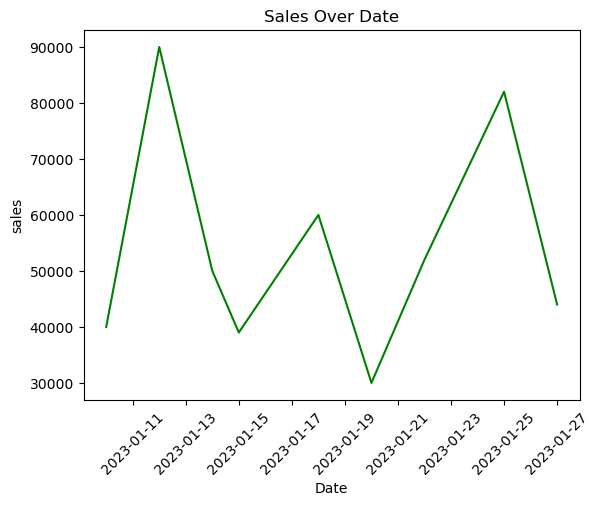

In [80]:
df=pd.DataFrame(df)
plt.plot(df['buydate'],df['sales'],color='g')
plt.xticks(rotation=45)
plt.ylabel('sales')
plt.xlabel('Date')
plt.title('Sales Over Date')
plt.show()

In [43]:
df=pd.read_sql('select productname,sum(sales) as sales from sales_data Group By productname',con=connection)
df

,productname,sales
0,Electronics,70000.0
1,clothing,134000.0
2,books,50000.0
3,sports,91000.0
4,beauty products,142000.0


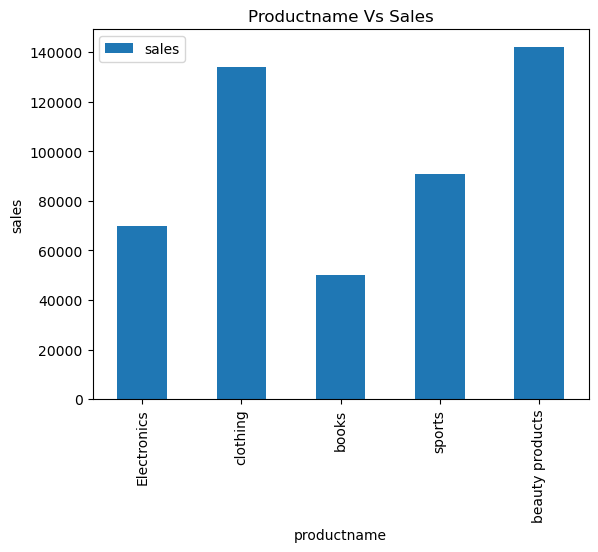

In [50]:
df.plot(kind='bar',x='productname',y='sales')
plt.ylabel('sales')
plt.title('Productname Vs Sales')
plt.show()

In [56]:
df=pd.read_sql('select name,sum(sales) as sales from sales_data Group By name',con=connection)
df

,name,sales
0,santhosh,40000.0
1,vamsee,90000.0
2,shanmukha,110000.0
3,thiru,39000.0
4,uday,30000.0
5,sai,52000.0
6,vignesh,82000.0
7,varun,44000.0


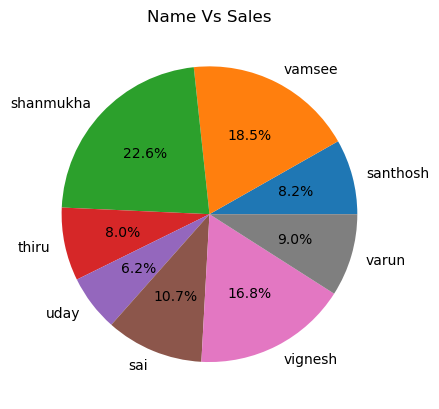

In [66]:
df=pd.DataFrame(df)
plt.pie(x=df['sales'],labels=df['name'],autopct='%1.1f%%')
plt.title('Name Vs Sales')
plt.show()